# **Step 1: Importing the  libraries**
Libraries for numerical calculations, array operations, plotting and visualizing data and images and other neccessary libraries for filtering images

In [1]:
import numpy as np
import pandas as pd
import cv2
from matplotlib import pyplot as plt
import bm3d
from scipy.signal import wiener
from pathlib import Path

# **Step 2: Uploading the image**
Uploading the image from local computer, reading the image from path in gray scale and clipping it between 0 and 1

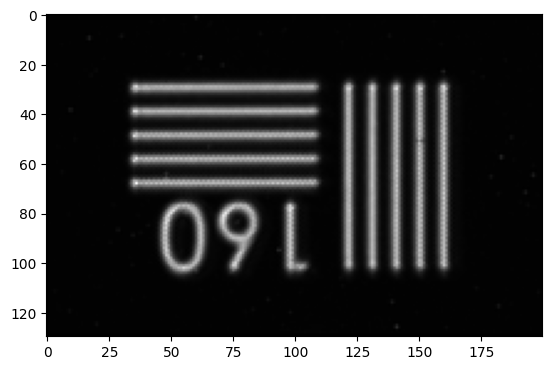

In [2]:
path = r"C:\AAKASH\MS_NOTES\4thsem\raml\dataset\final\Registered_Processed\1\1.png"     
image = cv2.imread(path, cv2.IMREAD_GRAYSCALE)     
image=image.astype(np.float32)/255          
plt.imshow(image,cmap='gray')

# **Step 3: Selection and addition of noise**
Asking the user which type of noise to be added

In [3]:
#Creating a function to ask the user to enter the noise level after selecting the type of noise
def input_for_noise_level():
    while True:
            try:
                noise_level = float(input("Enter an appropriate non negative Noise level (float value): "))  # Convert input to float
                break  # Exit if  successful
            except ValueError:
                print("Invalid noise level. It should be a floating-point number.")
    return noise_level

#Creating a function to do calcultions like adding noise to clean image and clipping it between 0 and 1 and convert the datatype to float32
def various_calc(image,noise):
    if(noise_type =="poisson"):
        noisy_image_clipped = np.clip(noise, 0, 1)  
        noisy_image = noisy_image_clipped.astype(np.float32)
    else:
        noisy_image_float = image + noise       
        noisy_image_clipped = np.clip(noisy_image_float, 0, 1)      
        noisy_image = noisy_image_clipped.astype(np.float32)
    return noisy_image

#Asking user to enter his choice of noise
noise_type = input("which noise you want to add, 'g' for gaussian, 'p' for poisson, 'u' for uniform and 'n' for none? (Enter 'g' or 'p' or 'u' or 'n'): ").strip().lower()
if noise_type == 'g':
    noise_type="gaussian"
    noise_level=input_for_noise_level()
    print("noise level entered for gaussian noise is",noise_level)
    noise = np.random.normal(0, noise_level / 255, size=image.shape)        #generating gausian noise using "np.random.normal" function
    noisy_image=various_calc(image,noise)
elif noise_type == 'p':
    noise_type="poisson"
    noise_level=input_for_noise_level()
    print("noise level entered poisson noise is",noise_level)
    noise = np.random.poisson(image * noise_level) / noise_level          #generating poisson noise using "np.random.poisson" function
    noisy_image=various_calc(image,noise)
elif noise_type == 'u':
    noise_type="uniform"
    noise_level=input_for_noise_level()
    print("noise level entered for uniform noise is",noise_level)
    noise=np.random.uniform(low=-noise_level/2, high=noise_level/2, size=image.shape)        #generating gausian noise using "np.random.uniform" function
    noisy_image=various_calc(image,noise)
elif noise_type == 'n':
    noise_type="non"
    noisy_image=image      #considering the clean or original image as noisy image
else:
     print("Enter valid option")


noise level entered poisson noise is 25.0


# **Step 4: Verification of previous steps and defining PSNR function**
Defining a function to  measure the quality of image and then displaying both the clean/original image and the noisy image in a layout along the PSNR value. also checking if the datatype of both these images is same so as to avoid any unseen computation error

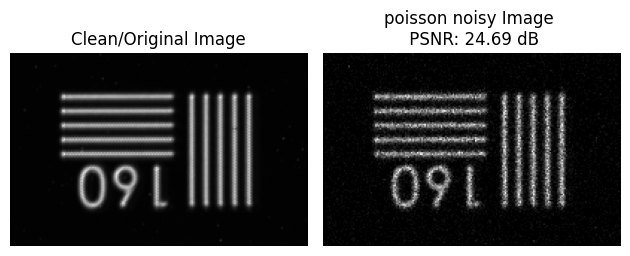

In [4]:

#defining the psnr metric
def calc_psnr(image,final_image):
    mse = np.mean((image - final_image) ** 2)   
    psnr = 10 * np.log10(1 / mse)       
    return psnr


#Creating a layout
plt.subplot(1, 2, 1) #Creating a subplot in the layout
plt.title('Clean/Original Image')
plt.imshow(image, cmap='gray')
plt.axis('off')  

psnr=calc_psnr(image,noisy_image)
plt.subplot(1, 2, 2) #Creating a subplot in the layout
plt.title(f"{noise_type} noisy Image \n PSNR: {psnr:.2f} dB")
plt.imshow(noisy_image, cmap='gray')
plt.axis('off') 

plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()


# **Step 5: Defining the filters and obtaining the denoised images along with PSNR values**
Defining the parameters required to filter the noisy images and then filtering the same and using 3 filers namely median, wiener and bm3d filter. 

In [5]:
#Defining the paramters for the filters
median_kernel=3 #should always be odd
wiener_kernel=3
sigma_psd=0.1

#Defining the median filter funtion
def median_filter(image,parameter):
    denoised_image = cv2.medianBlur(image, parameter)
    denoised_image = denoised_image.astype(np.float32)
    return denoised_image

#Defining the wiener filter funtion
def wiener_filter(image,parameter):
    noise_variance = np.var(image - cv2.blur(image, (parameter, parameter)))
    denoised_image= wiener(image, (parameter, parameter),noise_variance)
    denoised_image = denoised_image.astype(np.float32)
    return denoised_image

#Defining the bm3d filter funtion
def bm3d_filter(image,parameter):
    denoised_image = bm3d.bm3d(image, parameter)
    denoised_image = denoised_image.astype(np.float32)
    return denoised_image

#Generating the denoised images for the same image
mdenoised_image=median_filter(noisy_image,median_kernel)
wdenoised_image=wiener_filter(noisy_image,wiener_kernel)
bdenoised_image=bm3d_filter(noisy_image,sigma_psd)

#Computing the PSNR of the denoised images
psnr_m=calc_psnr(image,mdenoised_image)
psnr_w=calc_psnr(image,wdenoised_image)
psnr_b=calc_psnr(image,bdenoised_image)



# **Step 6: Creating a systematic image layout**
Ceating a layout to display the noisy image and then the denoised images with the 3 filters along with their PSNR value to visualise the results properly and then saving the plot/results in a desired loaction on the computer  

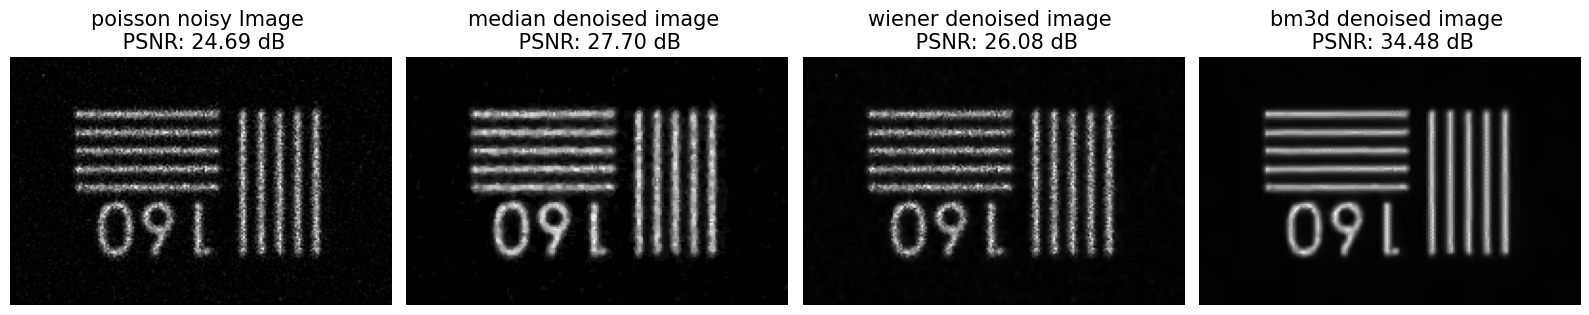

In [6]:
#defining each image to be included in the plot
image1=noisy_image
image2=mdenoised_image
image3=wdenoised_image
image4=bdenoised_image

#Creating a layout
plt.figure(figsize=(16, 5))

plt.subplot(1, 4, 1) #Creating a subplot in the layout
plt.title(f'{noise_type} noisy Image \n PSNR: {psnr:.2f} dB', fontsize=15)   #adding title along with the psnr value and adjusting the font size
plt.imshow(image1, cmap='gray')
plt.axis('off') 

plt.subplot(1, 4, 2) #Creating a subplot in the layout
plt.title(f'median denoised image \n PSNR: {psnr_m:.2f} dB', fontsize=15)
plt.imshow(image2, cmap='gray')
plt.axis('off') 

plt.subplot(1, 4, 3) #Creating a subplot in the layout
plt.title(f'wiener denoised image \n PSNR: {psnr_w:.2f} dB', fontsize=15)
plt.imshow(image3, cmap='gray')
plt.axis('off') 

plt.subplot(1, 4, 4) #Creating a subplot in the layout
plt.title(f'bm3d denoised image \n PSNR: {psnr_b:.2f} dB', fontsize=15)
plt.imshow(image4, cmap='gray')
plt.axis('off') 

plt.tight_layout()  # Adjust layout to prevent overlap

#results will be saved with the name of type of noise added 
save_path = fr'C:\AAKASH\MS_NOTES\4thsem\raml\dataset\final\Registered_Processed\1\{noise_type} results.png'        #path to save the results on PC
plt.savefig(save_path, bbox_inches='tight')

plt.show()      #to display the results
